In [1]:
import json,os,glob,anndata,random,gzip
import numpy as np
import pandas as pd
import scanpy as sc
import scipy
import scipy.sparse as sp
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import loompy

In [2]:
base_dir = "/n/fs/ragr-data/users/viola/structuredVAE/data"
paths_dict_file = "/n/fs/ragr-data/users/viola/mouse_dev/scripts/new_c_elegans/paths_dict_tree.json.gz"
print("Loading paths dictionary...")
def load_paths_dict(paths_dict_file):
    """Load the paths dictionary from the compressed JSON file."""
    with gzip.open(paths_dict_file, 'rt') as f:
        return json.load(f)
paths_dict = load_paths_dict(paths_dict_file)
scvae_paths = set()
scvi_paths = set()
for path_name in paths_dict.keys():
    scvae_path = os.path.join(base_dir, f"scvae_path_{path_name}", path_name)
    scvi_path = os.path.join(base_dir, f"scvi_path_{path_name}")
    if os.path.exists(scvae_path):
        scvae_paths.add(path_name)
    if os.path.exists(scvi_path):
        scvi_paths.add(path_name)

print(f"Found {len(scvae_paths)} scVAE paths")
print(f"Found {len(scvi_paths)} scVI paths")

# Find common paths
common_paths = scvae_paths.intersection(scvi_paths)
print(f"Found {len(common_paths)} paths that exist for both methods")

# Show some examples
print("\nExample common paths:")
for i, path in enumerate(sorted(common_paths)[:10]):
    print(f"  {i+1}. {path}")


Loading paths dictionary...
Found 1818 scVAE paths
Found 1828 scVI paths
Found 1818 paths that exist for both methods

Example common paths:
  1. ABa_ABalaaaalp
  2. ABa_ABalaaapar
  3. ABa_ABalaaappl
  4. ABa_ABalaapaap
  5. ABa_ABalpaaaaa
  6. ABa_ABalpaaaap
  7. ABa_ABalpaaapa
  8. ABa_ABalpaaapp
  9. ABa_ABalpappaa
  10. ABa_ABalpapppa


In [3]:
# Randomly select 50 paths from common paths
random.seed(42)  # For reproducibility

if len(common_paths) >= 50:
    selected_paths = random.sample(list(common_paths), 50)
    print(f"Randomly selected 50 paths from {len(common_paths)} common paths")
else:
    selected_paths = list(common_paths)
    print(f"Only {len(common_paths)} common paths available, using all of them")

print(f"\nSelected {len(selected_paths)} paths:")
for i, path in enumerate(selected_paths[:10]):  # Show first 10
    print(f"  {i+1}. {path}")
if len(selected_paths) > 10:
    print(f"  ... and {len(selected_paths) - 10} more")


Randomly selected 50 paths from 1818 common paths

Selected 50 paths:
  1. ABar_ABarpaaaapp
  2. ABplpa_ABplpapaaaa
  3. ABplpp_ABplppaaaaa
  4. EMS_MSpaapaa
  5. ABar_ABarpppppa
  6. MS_MSapaapp
  7. MSa_MSaapppaa
  8. P2_Dapaa
  9. P1_Dapap
  10. ABarpaa_ABarpaaaapp
  ... and 40 more


In [4]:
# Function to load AnnData for a given path
def load_anndata_for_path(path_name, method="both"):
    """
    Load AnnData objects for a given path name.
    
    Parameters:
    -----------
    path_name : str
        Name of the path
    method : str
        Which method to load data for: "scvae", "scvi", or "both"
    
    Returns:
    --------
    dict
        Dictionary containing loaded AnnData objects
    """
    results = {}
    
    if method in ["scvae", "both"]:
        # Load scVAE data
        scvae_dir = os.path.join(base_dir, f"scvae_path_{path_name}")
        loom_file = os.path.join(base_dir, f"{path_name}.loom")
        
        if os.path.exists(loom_file):
            try:
                adata_scvae = anndata.read_loom(loom_file)
                results['scvae'] = adata_scvae
                print(f"✓ Loaded scVAE data for {path_name}: {adata_scvae.shape}")
            except Exception as e:
                print(f"✗ Failed to load scVAE data for {path_name}: {e}")
                results['scvae'] = None
        else:
            print(f"✗ Loom file not found for {path_name}: {loom_file}")
            results['scvae'] = None
    
    if method in ["scvi", "both"]:
        # Load scVI data
        scvi_dir = os.path.join(base_dir, f"scvi_path_{path_name}")
        h5ad_file = os.path.join(scvi_dir, "trained.h5ad")
        
        if os.path.exists(h5ad_file):
            try:
                adata_scvi = anndata.read_h5ad(h5ad_file)
                results['scvi'] = adata_scvi
                print(f"✓ Loaded scVI data for {path_name}: {adata_scvi.shape}")
            except Exception as e:
                print(f"✗ Failed to load scVI data for {path_name}: {e}")
                results['scvi'] = None
        else:
            print(f"✗ H5AD file not found for {path_name}: {h5ad_file}")
            results['scvi'] = None
    
    return results

# Test loading for first few paths
print("Testing data loading for first 3 paths:")
for i, path_name in enumerate(selected_paths[:3]):
    print(f"\n--- Path {i+1}: {path_name} ---")
    data = load_anndata_for_path(path_name, method="both")


Testing data loading for first 3 paths:

--- Path 1: ABar_ABarpaaaapp ---


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


✓ Loaded scVAE data for ABar_ABarpaaaapp: (285, 2000)
✓ Loaded scVI data for ABar_ABarpaaaapp: (285, 2000)

--- Path 2: ABplpa_ABplpapaaaa ---
✓ Loaded scVAE data for ABplpa_ABplpapaaaa: (532, 2000)


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


✓ Loaded scVI data for ABplpa_ABplpapaaaa: (532, 2000)

--- Path 3: ABplpp_ABplppaaaaa ---


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


✓ Loaded scVAE data for ABplpp_ABplppaaaaa: (447, 2000)
✓ Loaded scVI data for ABplpp_ABplppaaaaa: (447, 2000)


In [5]:
# Load all selected paths and store in a dictionary
all_data = {}
successful_loads = 0

print(f"Loading data for all {len(selected_paths)} selected paths...")
print("=" * 60)

for i, path_name in enumerate(selected_paths):
    print(f"\n[{i+1}/{len(selected_paths)}] Loading {path_name}...")
    
    try:
        data = load_anndata_for_path(path_name, method="both")
        
        # Check if both methods loaded successfully
        if data.get('scvae') is not None and data.get('scvi') is not None:
            all_data[path_name] = data
            successful_loads += 1
            print(f"✓ Successfully loaded both methods for {path_name}")
        else:
            print(f"✗ Failed to load both methods for {path_name}")
            
    except Exception as e:
        print(f"✗ Error loading {path_name}: {e}")

print(f"\n" + "=" * 60)
print(f"Successfully loaded {successful_loads}/{len(selected_paths)} paths with both methods")
print(f"Available paths: {list(all_data.keys())[:5]}{'...' if len(all_data) > 5 else ''}")


Loading data for all 50 selected paths...

[1/50] Loading ABar_ABarpaaaapp...
✓ Loaded scVAE data for ABar_ABarpaaaapp: (285, 2000)


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


✓ Loaded scVI data for ABar_ABarpaaaapp: (285, 2000)
✓ Successfully loaded both methods for ABar_ABarpaaaapp

[2/50] Loading ABplpa_ABplpapaaaa...
✓ Loaded scVAE data for ABplpa_ABplpapaaaa: (532, 2000)


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


✓ Loaded scVI data for ABplpa_ABplpapaaaa: (532, 2000)
✓ Successfully loaded both methods for ABplpa_ABplpapaaaa

[3/50] Loading ABplpp_ABplppaaaaa...
✓ Loaded scVAE data for ABplpp_ABplppaaaaa: (447, 2000)


...

✓ Loaded scVAE data for ABal_ABalppappaa: (497, 2000)
✓ Loaded scVI data for ABal_ABalppappaa: (497, 2000)
✓ Successfully loaded both methods for ABal_ABalppappaa

[49/50] Loading Cp_Cpppapp...
✓ Loaded scVAE data for Cp_Cpppapp: (435, 2000)


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


✓ Loaded scVI data for Cp_Cpppapp: (435, 2000)
✓ Successfully loaded both methods for Cp_Cpppapp

[50/50] Loading ABplaa_ABplaaaaappa...


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


✓ Loaded scVAE data for ABplaa_ABplaaaaappa: (491, 2000)
✓ Loaded scVI data for ABplaa_ABplaaaaappa: (491, 2000)
✓ Successfully loaded both methods for ABplaa_ABplaaaaappa

Successfully loaded 50/50 paths with both methods
Available paths: ['ABar_ABarpaaaapp', 'ABplpa_ABplpapaaaa', 'ABplpp_ABplppaaaaa', 'EMS_MSpaapaa', 'ABar_ABarpppppa']...


In [6]:
# Simple analysis functions for testing
def basic_data_summary(adata, method_name):
    """Print basic summary statistics for an AnnData object."""
    print(f"\n--- {method_name} Data Summary ---")
    print(f"Shape: {adata.shape}")
    print(f"Number of cells: {adata.n_obs}")
    print(f"Number of genes: {adata.n_vars}")
    
    if 'lineage' in adata.obs.columns:
        unique_lineages = adata.obs['lineage'].nunique()
        print(f"Number of unique lineages: {unique_lineages}")
        print(f"Lineage distribution:")
        lineage_counts = adata.obs['lineage'].value_counts()
        print(lineage_counts.head())
    
    # Check for latent representations
    if 'X_scVI' in adata.obsm:
        print(f"scVI latent representation shape: {adata.obsm['X_scVI'].shape}")
    
    return adata.shape

def compare_methods(path_name, data_dict):
    """Compare scVAE and scVI data for a given path."""
    print(f"\n{'='*50}")
    print(f"COMPARISON FOR PATH: {path_name}")
    print(f"{'='*50}")
    
    scvae_data = data_dict.get('scvae')
    scvi_data = data_dict.get('scvi')
    
    if scvae_data is None or scvi_data is None:
        print("Missing data for one or both methods")
        return None
    
    # Basic summaries
    scvae_shape = basic_data_summary(scvae_data, "scVAE")
    scvi_shape = basic_data_summary(scvi_data, "scVI")
    
    # Compare shapes
    if scvae_shape == scvi_shape:
        print(f"\n✓ Both methods have same data shape: {scvae_shape}")
    else:
        print(f"\n✗ Different shapes - scVAE: {scvae_shape}, scVI: {scvi_shape}")
    
    return {
        'path_name': path_name,
        'scvae_shape': scvae_shape,
        'scvi_shape': scvi_shape,
        'shapes_match': scvae_shape == scvi_shape
    }

# Test the comparison function on a few paths
print("Testing comparison function on first 3 successfully loaded paths:")
test_paths = list(all_data.keys())[:3]

for path_name in test_paths:
    comparison_result = compare_methods(path_name, all_data[path_name])


Testing comparison function on first 3 successfully loaded paths:

COMPARISON FOR PATH: ABar_ABarpaaaapp

--- scVAE Data Summary ---
Shape: (285, 2000)
Number of cells: 285
Number of genes: 2000
Number of unique lineages: 7
Lineage distribution:
lineage
ABarpaaaapp/ABarpaaapap/ABpxpaaapap    116
ABarpaaa                                42
ABarpaaaa                               41
ABarpaaaap/ABarpaaapa                   36
ABaxx                                   27
Name: count, dtype: int64

--- scVI Data Summary ---
Shape: (285, 2000)
Number of cells: 285
Number of genes: 2000
Number of unique lineages: 7
Lineage distribution:
lineage
ABarpaaaapp/ABarpaaapap/ABpxpaaapap    116
ABarpaaa                                42
ABarpaaaa                               41
ABarpaaaap/ABarpaaapa                   36
ABaxx                                   27
Name: count, dtype: int64
scVI latent representation shape: (285, 1)

✓ Both methods have same data shape: (285, 2000)

COMPARISON FOR PATH: A

In [7]:
# Summary of all loaded data
print(f"\n{'='*60}")
print("SUMMARY OF ALL LOADED DATA")
print(f"{'='*60}")

comparison_results = []

for path_name, data_dict in all_data.items():
    result = compare_methods(path_name, data_dict)
    if result:
        comparison_results.append(result)

# Create summary DataFrame
if comparison_results:
    summary_df = pd.DataFrame(comparison_results)
    print(f"\n--- Summary Statistics ---")
    print(f"Total paths analyzed: {len(summary_df)}")
    print(f"Paths with matching shapes: {summary_df['shapes_match'].sum()}")
    print(f"Paths with different shapes: {(~summary_df['shapes_match']).sum()}")
    
    print(f"\n--- Shape Distribution ---")
    print(summary_df[['path_name', 'scvae_shape', 'scvi_shape', 'shapes_match']].head(10))
    
    # Save results
    output_file = "/n/fs/ragr-data/users/viola/structuredVAE/results/simple_methods_comparison.csv"
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    summary_df.to_csv(output_file, index=False)
    print(f"\nResults saved to: {output_file}")
else:
    print("No successful comparisons to summarize")



SUMMARY OF ALL LOADED DATA

COMPARISON FOR PATH: ABar_ABarpaaaapp

--- scVAE Data Summary ---
Shape: (285, 2000)
Number of cells: 285
Number of genes: 2000
Number of unique lineages: 7
Lineage distribution:
lineage
ABarpaaaapp/ABarpaaapap/ABpxpaaapap    116
ABarpaaa                                42
ABarpaaaa                               41
ABarpaaaap/ABarpaaapa                   36
ABaxx                                   27
Name: count, dtype: int64

--- scVI Data Summary ---
Shape: (285, 2000)
Number of cells: 285
Number of genes: 2000
Number of unique lineages: 7
Lineage distribution:
lineage
ABarpaaaapp/ABarpaaapap/ABpxpaaapap    116
ABarpaaa                                42
ABarpaaaa                               41
ABarpaaaap/ABarpaaapa                   36
ABaxx                                   27
Name: count, dtype: int64
scVI latent representation shape: (285, 1)

✓ Both methods have same data shape: (285, 2000)

COMPARISON FOR PATH: ABplpa_ABplpapaaaa

--- scVAE Data Summ

In [8]:
# Import additional libraries for PCA and UMAP
import umap
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")


In [9]:
# Function to perform PCA and 1D UMAP analysis
def analyze_pca_umap(adata, method_name, n_pca_components=50):
    """
    Perform PCA (50 components) and 1D UMAP analysis on AnnData object.
    
    Parameters:
    -----------
    adata : AnnData
        AnnData object to analyze
    method_name : str
        Name of the method (for logging)
    n_pca_components : int
        Number of PCA components (default: 50)
    
    Returns:
    --------
    dict
        Dictionary containing PCA and UMAP results
    """
    print(f"\n--- {method_name} PCA + 1D UMAP Analysis ---")
    
    try:
        # Get expression data (use raw counts if available, otherwise X)
        if adata.raw is not None:
            X = adata.raw.X
        else:
            X = adata.X
        
        # Convert to dense if sparse
        if sp.issparse(X):
            X = X.toarray()
        
        print(f"Input data shape: {X.shape}")
        
        # Standardize the data
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        print(f"Data standardized")
        
        # Perform PCA
        pca = PCA(n_components=n_pca_components, random_state=42)
        X_pca = pca.fit_transform(X_scaled)
        print(f"PCA completed: {X_pca.shape}")
        print(f"Explained variance ratio (first 10 components): {pca.explained_variance_ratio_[:10]}")
        print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.3f}")
        
        # Perform 1D UMAP
        umap_1d = umap.UMAP(n_components=1, random_state=42, n_neighbors=15, min_dist=0.1)
        X_umap_1d = umap_1d.fit_transform(X_pca)
        print(f"1D UMAP completed: {X_umap_1d.shape}")
        
        # Store results in adata
        adata.obsm['X_pca'] = X_pca
        adata.obsm['X_umap_1d'] = X_umap_1d.flatten()
        
        return {
            'pca': pca,
            'umap_1d': umap_1d,
            'X_pca': X_pca,
            'X_umap_1d': X_umap_1d.flatten(),
            'explained_variance_ratio': pca.explained_variance_ratio_,
            'total_explained_variance': pca.explained_variance_ratio_.sum()
        }
        
    except Exception as e:
        print(f"Error in PCA/UMAP analysis for {method_name}: {e}")
        return None


In [13]:
# Function to create overlapping histogram plot with 1D UMAP and lineage coloring
def plot_label_overlaid_hists(df, order, bins=50, title="Frequency Distributions by Label", xlabel="1D latent", figsize=(7,3.5), legend_ncol=2):
    plt.figure(figsize=figsize)
    for lab in order:
        vals = df.loc[df["label"] == lab, "z"].values
        plt.hist(vals, bins=bins, alpha=0.5, density=True, label=str(lab))
    plt.xlabel(xlabel)
    plt.ylabel("Frequency")
    plt.title(title)
    plt.legend(frameon=False, ncol=legend_ncol, fontsize=8)
    plt.tight_layout()
    plt.show()

def create_umap_lineage_histogram(adata, method_name, path_name, n_bins=50, normalize=True):
    """
    Create overlapping histograms with 1D UMAP on x-axis, frequency on y-axis, colored by lineage.
    Uses plot_label_overlaid_hist function to match the reference plot style.
    
    Parameters:
    -----------
    adata : AnnData
        AnnData object with UMAP results
    method_name : str
        Name of the method (for plot title)
    path_name : str
        Name of the path (for plot title)
    n_bins : int
        Number of bins for histogram (default: 50)
    normalize : bool
        Whether to normalize frequencies (default: True)
    
    Returns:
    --------
    matplotlib.figure.Figure
        The created figure
    """
    if 'X_umap_1d' not in adata.obsm:
        print(f"No 1D UMAP data found for {method_name}")
        return None
    
    if 'lineage' not in adata.obs.columns:
        print(f"No lineage information found for {method_name}")
        return None
    
    # Get UMAP 1D values and lineage information
    umap_1d = adata.obsm['X_umap_1d']
    lineages = adata.obs['lineage']
    
    # Create DataFrame for plot_label_overlaid_hist function
    df = pd.DataFrame({
        'z': umap_1d.flatten(),
        'label': lineages.values
    })
    
    # Get unique lineages in order
    unique_lineages = sorted(lineages.unique())
    
    # Create the plot using plot_label_overlaid_hist
    plot_label_overlaid_hists(
        df, 
        unique_lineages, 
        bins=n_bins, 
        title=f"Frequency Distributions by Label (normalized)" if normalize else f"Frequency Distributions by Label",
        xlabel=method_name+"_z",
        figsize=(7, 3.5),
        legend_ncol=2
    )
    
    # Return the current figure
    return plt.gcf()


Testing analysis on first path: ABar_ABarpaaaapp

TESTING PCA+UMAP+HISTOGRAM ANALYSIS FOR: ABar_ABarpaaaapp

--- Analyzing scVAE data ---

--- scVAE PCA + 1D UMAP Analysis ---
Input data shape: (285, 2000)
Data standardized


PCA completed: (285, 50)
Explained variance ratio (first 10 components): [0.03669458 0.02850175 0.02358405 0.01968288 0.01905103 0.01867571
 0.01584258 0.01498177 0.01332058 0.01269677]
Total explained variance: 0.503


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (285, 1)


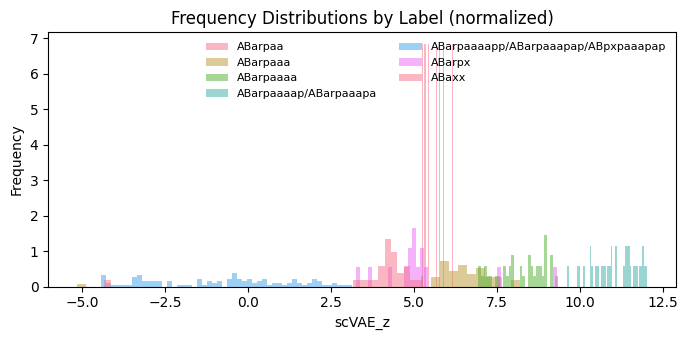

<Figure size 640x480 with 0 Axes>


--- Analyzing scVI data ---

--- scVI PCA + 1D UMAP Analysis ---
Input data shape: (285, 20222)
Data standardized
PCA completed: (285, 50)
Explained variance ratio (first 10 components): [0.1273463  0.02840712 0.02150959 0.01796219 0.01594408 0.01449809
 0.01369855 0.0123798  0.01211491 0.0111142 ]
Total explained variance: 0.556


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (285, 1)


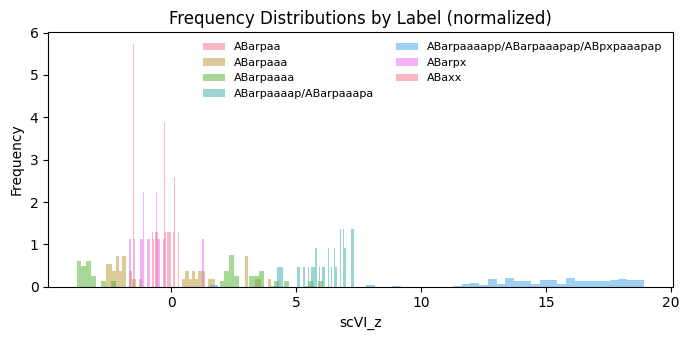

<Figure size 640x480 with 0 Axes>

In [14]:
# Test the PCA+UMAP+histogram analysis on a single path
def test_single_path_analysis(path_name, data_dict):
    """Test PCA+UMAP+histogram analysis on a single path."""
    print(f"\n{'='*60}")
    print(f"TESTING PCA+UMAP+HISTOGRAM ANALYSIS FOR: {path_name}")
    print(f"{'='*60}")
    
    scvae_data = data_dict.get('scvae')
    scvi_data = data_dict.get('scvi')
    
    if scvae_data is None or scvi_data is None:
        print("Missing data for one or both methods")
        return None
    
    results = {}
    
    # Analyze scVAE data
    print(f"\n--- Analyzing scVAE data ---")
    scvae_results = analyze_pca_umap(scvae_data, "scVAE")
    if scvae_results:
        results['scvae'] = scvae_results
        # Create histogram for scVAE
        fig_scvae = create_umap_lineage_histogram(scvae_data, "scVAE", path_name)
        if fig_scvae:
            plt.show()
            plt.close()
    
    # Analyze scVI data
    print(f"\n--- Analyzing scVI data ---")
    scvi_results = analyze_pca_umap(scvi_data, "scVI")
    if scvi_results:
        results['scvi'] = scvi_results
        # Create histogram for scVI
        fig_scvi = create_umap_lineage_histogram(scvi_data, "scVI", path_name)
        if fig_scvi:
            plt.show()
            plt.close()
    
    return results

# Test on the first available path
if all_data:
    first_path = list(all_data.keys())[0]
    print(f"Testing analysis on first path: {first_path}")
    test_results = test_single_path_analysis(first_path, all_data[first_path])
else:
    print("No data available for testing")


Running analysis on all paths...

RUNNING PCA+UMAP+HISTOGRAM ANALYSIS ON ALL PATHS
Analyzing 20 paths...

[1/20] Analyzing ABar_ABarpaaaapp...

TESTING PCA+UMAP+HISTOGRAM ANALYSIS FOR: ABar_ABarpaaaapp

--- Analyzing scVAE data ---

--- scVAE PCA + 1D UMAP Analysis ---
Input data shape: (285, 2000)
Data standardized
PCA completed: (285, 50)
Explained variance ratio (first 10 components): [0.03669458 0.02850175 0.02358405 0.01968288 0.01905103 0.01867571
 0.01584258 0.01498177 0.01332058 0.01269677]
Total explained variance: 0.503


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (285, 1)


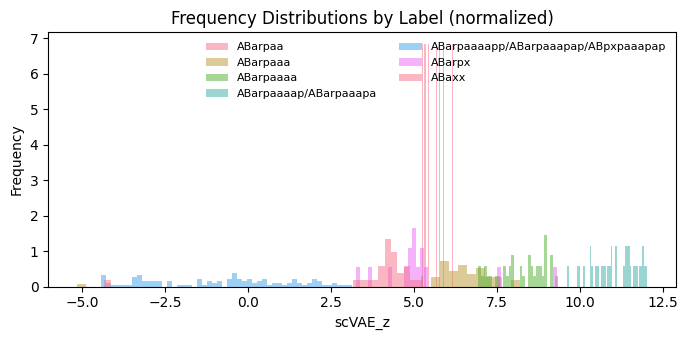

<Figure size 640x480 with 0 Axes>


--- Analyzing scVI data ---

--- scVI PCA + 1D UMAP Analysis ---
Input data shape: (285, 20222)
Data standardized
PCA completed: (285, 50)
Explained variance ratio (first 10 components): [0.1273463  0.02840712 0.02150959 0.01796219 0.01594408 0.01449809
 0.01369855 0.0123798  0.01211491 0.0111142 ]
Total explained variance: 0.556


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (285, 1)


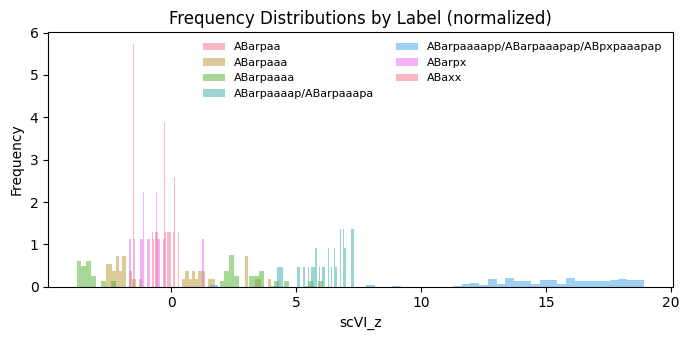

<Figure size 640x480 with 0 Axes>

✓ Successfully analyzed ABar_ABarpaaaapp

[2/20] Analyzing ABplpa_ABplpapaaaa...

TESTING PCA+UMAP+HISTOGRAM ANALYSIS FOR: ABplpa_ABplpapaaaa

--- Analyzing scVAE data ---

--- scVAE PCA + 1D UMAP Analysis ---
Input data shape: (532, 2000)
Data standardized
PCA completed: (532, 50)
Explained variance ratio (first 10 components): [0.02516542 0.01604773 0.01018762 0.00976923 0.00933469 0.00883497
 0.00861731 0.00834933 0.00818413 0.0080578 ]
Total explained variance: 0.339


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (532, 1)


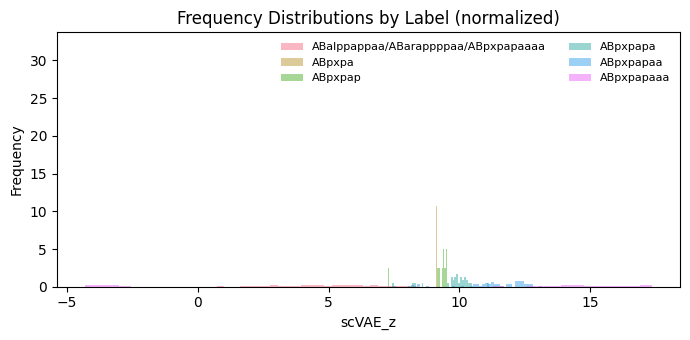

<Figure size 640x480 with 0 Axes>


--- Analyzing scVI data ---

--- scVI PCA + 1D UMAP Analysis ---
Input data shape: (532, 20222)
Data standardized
PCA completed: (532, 50)
Explained variance ratio (first 10 components): [0.05999606 0.01468108 0.01137757 0.01079296 0.01010969 0.00930814
 0.00851343 0.00727983 0.00712187 0.00646786]
Total explained variance: 0.321


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (532, 1)


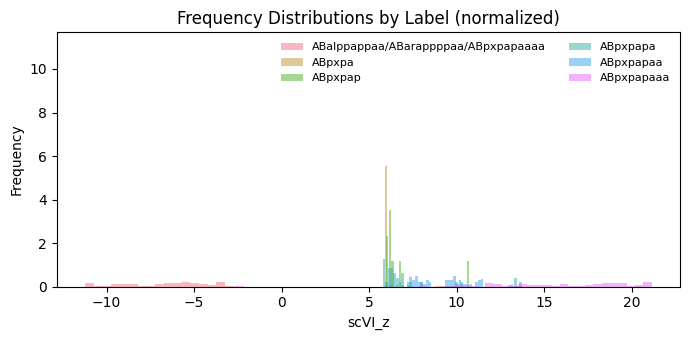

<Figure size 640x480 with 0 Axes>

✓ Successfully analyzed ABplpa_ABplpapaaaa

[3/20] Analyzing ABplpp_ABplppaaaaa...

TESTING PCA+UMAP+HISTOGRAM ANALYSIS FOR: ABplpp_ABplppaaaaa

--- Analyzing scVAE data ---

--- scVAE PCA + 1D UMAP Analysis ---
Input data shape: (447, 2000)
Data standardized
PCA completed: (447, 50)
Explained variance ratio (first 10 components): [0.02831689 0.02324867 0.01841402 0.01646769 0.01445557 0.01114672
 0.01097159 0.00985876 0.00944992 0.00900644]
Total explained variance: 0.396


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (447, 1)


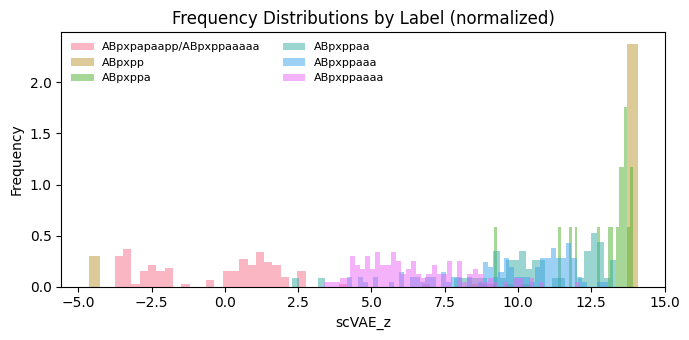

<Figure size 640x480 with 0 Axes>


--- Analyzing scVI data ---

--- scVI PCA + 1D UMAP Analysis ---
Input data shape: (447, 20222)
Data standardized
PCA completed: (447, 50)
Explained variance ratio (first 10 components): [0.0607721  0.01534712 0.01398037 0.01213968 0.01080848 0.00997371
 0.00944435 0.00912852 0.00885742 0.00869421]
Total explained variance: 0.342


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (447, 1)


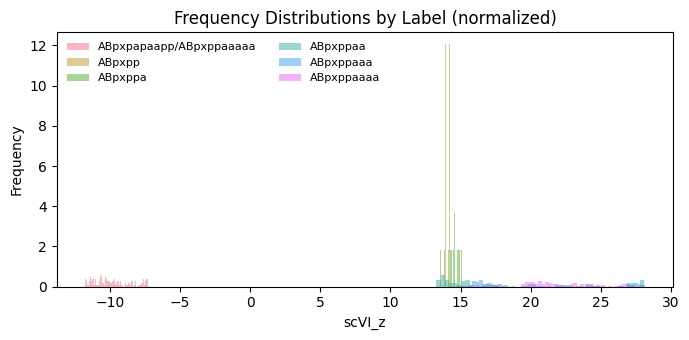

<Figure size 640x480 with 0 Axes>

✓ Successfully analyzed ABplpp_ABplppaaaaa

[4/20] Analyzing EMS_MSpaapaa...

TESTING PCA+UMAP+HISTOGRAM ANALYSIS FOR: EMS_MSpaapaa

--- Analyzing scVAE data ---

--- scVAE PCA + 1D UMAP Analysis ---
Input data shape: (249, 2000)
Data standardized
PCA completed: (249, 50)
Explained variance ratio (first 10 components): [0.05083644 0.04027374 0.02912022 0.02570147 0.02229057 0.02093245
 0.01867601 0.01754647 0.01661111 0.01543194]
Total explained variance: 0.586


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (249, 1)


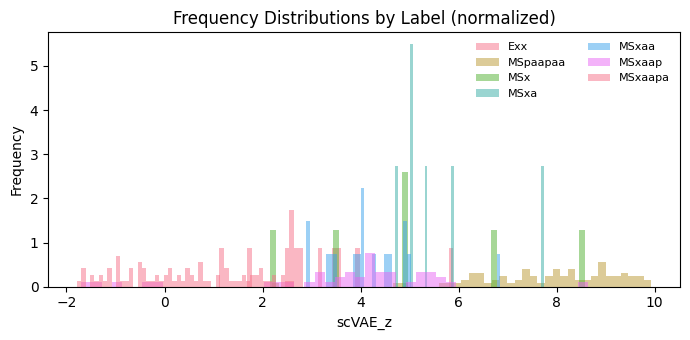

<Figure size 640x480 with 0 Axes>


--- Analyzing scVI data ---

--- scVI PCA + 1D UMAP Analysis ---
Input data shape: (249, 20222)
Data standardized
PCA completed: (249, 50)
Explained variance ratio (first 10 components): [0.09261449 0.04842359 0.02858651 0.02627462 0.02364729 0.02141256
 0.02034195 0.0171413  0.01582772 0.01441238]
Total explained variance: 0.565


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (249, 1)


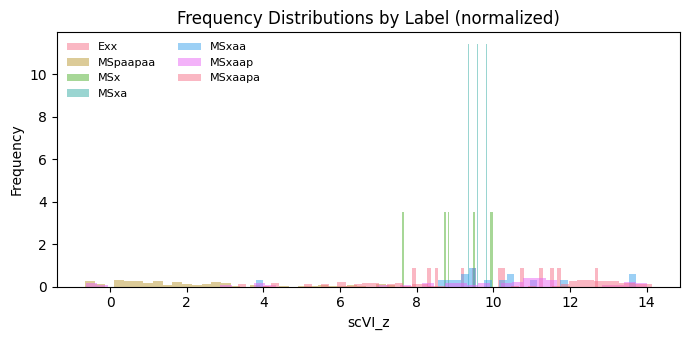

<Figure size 640x480 with 0 Axes>

✓ Successfully analyzed EMS_MSpaapaa

[5/20] Analyzing ABar_ABarpppppa...

TESTING PCA+UMAP+HISTOGRAM ANALYSIS FOR: ABar_ABarpppppa

--- Analyzing scVAE data ---

--- scVAE PCA + 1D UMAP Analysis ---
Input data shape: (243, 2000)
Data standardized
PCA completed: (243, 50)
Explained variance ratio (first 10 components): [0.0461062  0.03686062 0.03113445 0.02461552 0.02185633 0.01903593
 0.01588235 0.01560971 0.01514855 0.0138551 ]
Total explained variance: 0.566


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (243, 1)


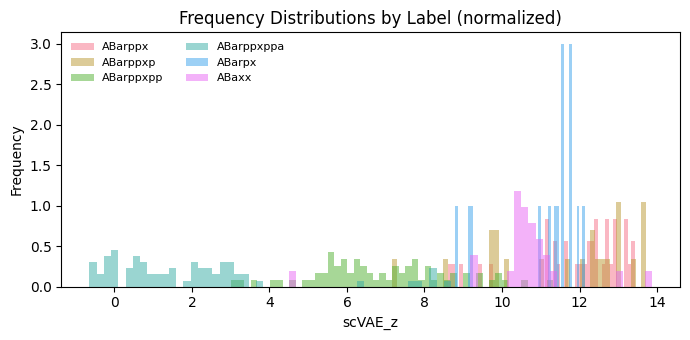

<Figure size 640x480 with 0 Axes>


--- Analyzing scVI data ---

--- scVI PCA + 1D UMAP Analysis ---
Input data shape: (243, 20222)
Data standardized
PCA completed: (243, 50)
Explained variance ratio (first 10 components): [0.10683747 0.02792359 0.02178626 0.01750427 0.01684906 0.01485231
 0.01443955 0.01332295 0.01218133 0.01138999]
Total explained variance: 0.543


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (243, 1)


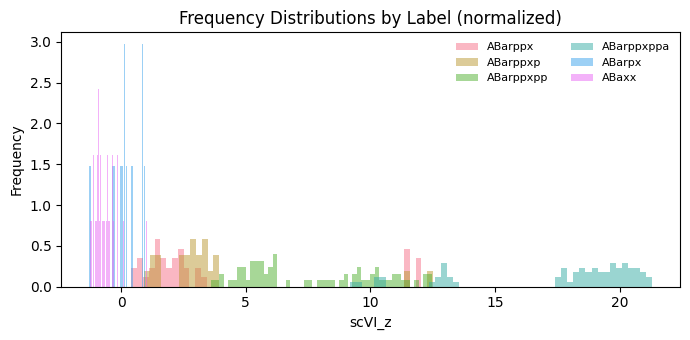

<Figure size 640x480 with 0 Axes>

✓ Successfully analyzed ABar_ABarpppppa

[6/20] Analyzing MS_MSapaapp...

TESTING PCA+UMAP+HISTOGRAM ANALYSIS FOR: MS_MSapaapp

--- Analyzing scVAE data ---

--- scVAE PCA + 1D UMAP Analysis ---
Input data shape: (387, 2000)
Data standardized
PCA completed: (387, 50)
Explained variance ratio (first 10 components): [0.03188589 0.01838601 0.01796121 0.0145266  0.01343001 0.01308521
 0.01278062 0.0121491  0.01156624 0.01039968]
Total explained variance: 0.423


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (387, 1)


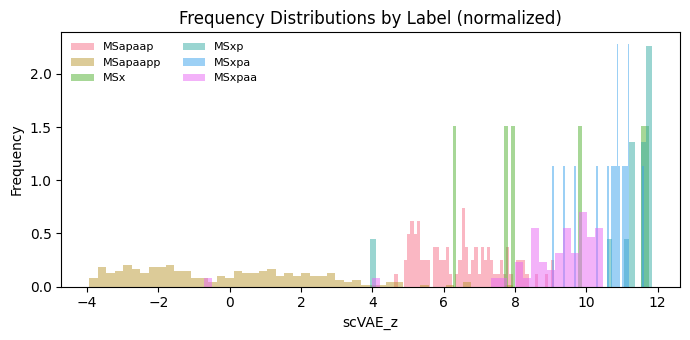

<Figure size 640x480 with 0 Axes>


--- Analyzing scVI data ---

--- scVI PCA + 1D UMAP Analysis ---
Input data shape: (387, 20222)
Data standardized
PCA completed: (387, 50)
Explained variance ratio (first 10 components): [0.08356787 0.02513727 0.0206797  0.01766194 0.01607702 0.0126644
 0.00955831 0.00924429 0.00904466 0.00855393]
Total explained variance: 0.414


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (387, 1)


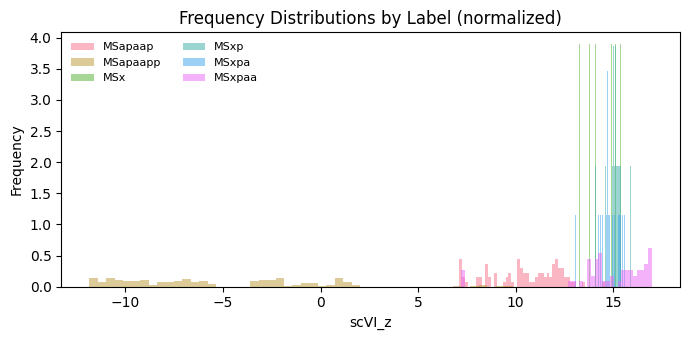

<Figure size 640x480 with 0 Axes>

✓ Successfully analyzed MS_MSapaapp

[7/20] Analyzing MSa_MSaapppaa...

TESTING PCA+UMAP+HISTOGRAM ANALYSIS FOR: MSa_MSaapppaa

--- Analyzing scVAE data ---

--- scVAE PCA + 1D UMAP Analysis ---
Input data shape: (580, 2000)
Data standardized
PCA completed: (580, 50)
Explained variance ratio (first 10 components): [0.03744214 0.01933782 0.01620576 0.01460252 0.01364377 0.01103037
 0.01040155 0.01031864 0.00954183 0.00884238]
Total explained variance: 0.390


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (580, 1)


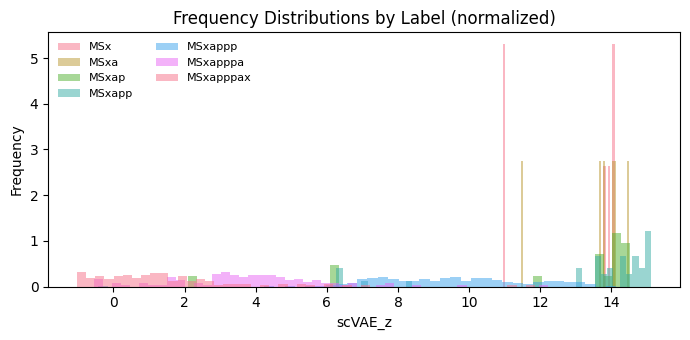

<Figure size 640x480 with 0 Axes>


--- Analyzing scVI data ---

--- scVI PCA + 1D UMAP Analysis ---
Input data shape: (580, 20222)
Data standardized
PCA completed: (580, 50)
Explained variance ratio (first 10 components): [0.07180756 0.02443618 0.01911419 0.01660202 0.01246096 0.01029371
 0.00920862 0.00756568 0.0073697  0.00714671]
Total explained variance: 0.349


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (580, 1)


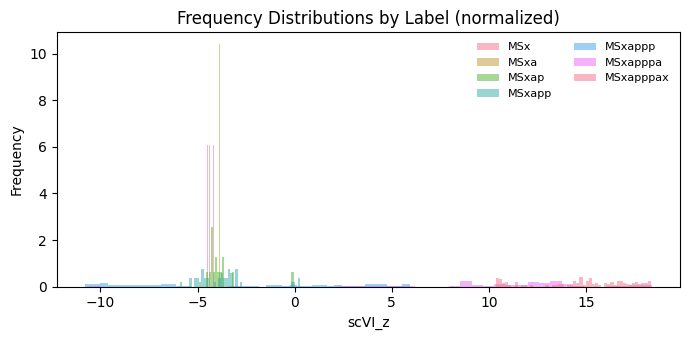

<Figure size 640x480 with 0 Axes>

✓ Successfully analyzed MSa_MSaapppaa

[8/20] Analyzing P2_Dapaa...

TESTING PCA+UMAP+HISTOGRAM ANALYSIS FOR: P2_Dapaa

--- Analyzing scVAE data ---

--- scVAE PCA + 1D UMAP Analysis ---
Input data shape: (651, 2000)
Data standardized
PCA completed: (651, 50)
Explained variance ratio (first 10 components): [0.02746341 0.01571309 0.01401629 0.01361655 0.01025552 0.00999381
 0.00959989 0.00945925 0.00897955 0.00826458]
Total explained variance: 0.349


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (651, 1)


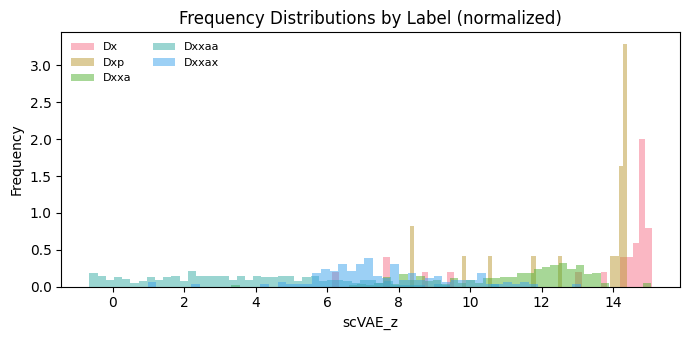

<Figure size 640x480 with 0 Axes>


--- Analyzing scVI data ---

--- scVI PCA + 1D UMAP Analysis ---
Input data shape: (651, 20222)
Data standardized
PCA completed: (651, 50)
Explained variance ratio (first 10 components): [0.05499364 0.01678812 0.00979155 0.00953026 0.00820706 0.00781572
 0.00746284 0.00739464 0.00703015 0.00661451]
Total explained variance: 0.300


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (651, 1)


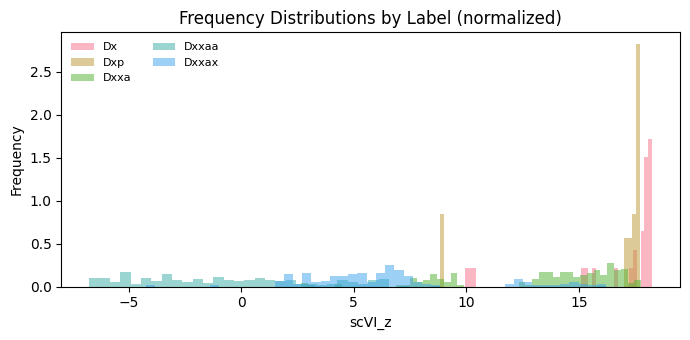

<Figure size 640x480 with 0 Axes>

✓ Successfully analyzed P2_Dapaa

[9/20] Analyzing P1_Dapap...

TESTING PCA+UMAP+HISTOGRAM ANALYSIS FOR: P1_Dapap

--- Analyzing scVAE data ---

--- scVAE PCA + 1D UMAP Analysis ---
Input data shape: (494, 2000)
Data standardized
PCA completed: (494, 50)
Explained variance ratio (first 10 components): [0.02945159 0.01876506 0.01719885 0.01292001 0.0117837  0.01122014
 0.01094266 0.01065696 0.01012164 0.00982323]
Total explained variance: 0.394


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (494, 1)


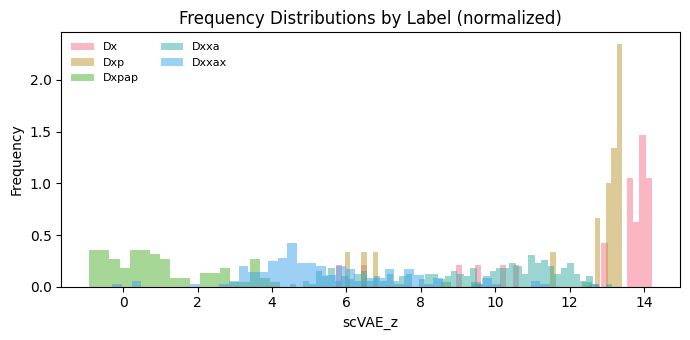

<Figure size 640x480 with 0 Axes>


--- Analyzing scVI data ---

--- scVI PCA + 1D UMAP Analysis ---
Input data shape: (494, 20222)
Data standardized
PCA completed: (494, 50)
Explained variance ratio (first 10 components): [0.05604756 0.01805617 0.01114829 0.00919782 0.00881382 0.00841393
 0.00830096 0.00798597 0.00740789 0.00725758]
Total explained variance: 0.327


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (494, 1)


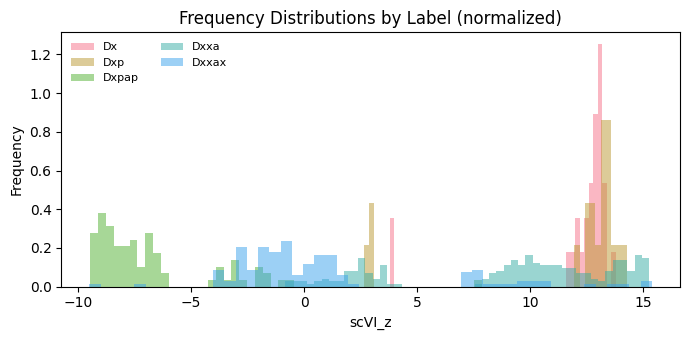

<Figure size 640x480 with 0 Axes>

✓ Successfully analyzed P1_Dapap

[10/20] Analyzing ABarpaa_ABarpaaaapp...

TESTING PCA+UMAP+HISTOGRAM ANALYSIS FOR: ABarpaa_ABarpaaaapp

--- Analyzing scVAE data ---

--- scVAE PCA + 1D UMAP Analysis ---
Input data shape: (243, 2000)
Data standardized
PCA completed: (243, 50)
Explained variance ratio (first 10 components): [0.03472796 0.02959706 0.02220154 0.01985913 0.01575371 0.01515494
 0.01419401 0.01312754 0.01279784 0.01251975]
Total explained variance: 0.494


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (243, 1)


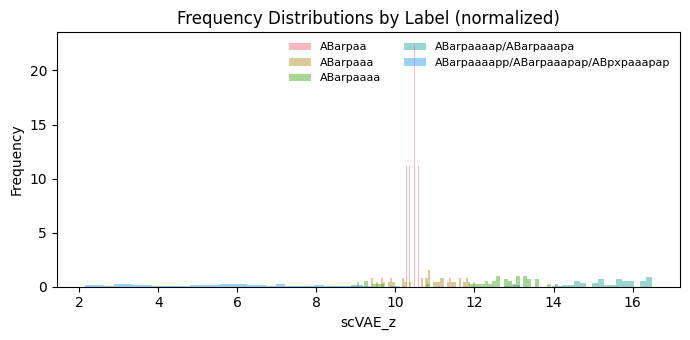

<Figure size 640x480 with 0 Axes>


--- Analyzing scVI data ---

--- scVI PCA + 1D UMAP Analysis ---
Input data shape: (243, 20222)
Data standardized
PCA completed: (243, 50)
Explained variance ratio (first 10 components): [0.08963402 0.02560065 0.02244008 0.01759705 0.01650137 0.0137076
 0.0128289  0.01153211 0.0108801  0.01055333]
Total explained variance: 0.503


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (243, 1)


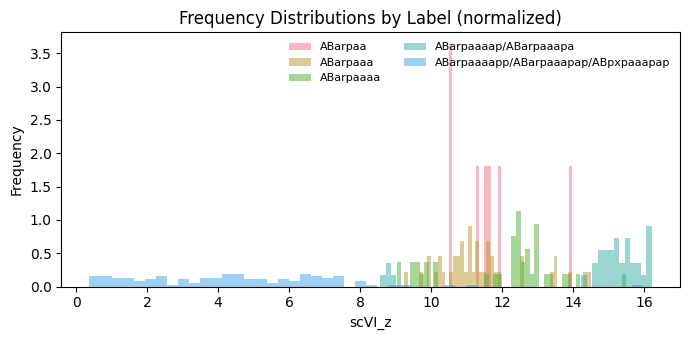

<Figure size 640x480 with 0 Axes>

✓ Successfully analyzed ABarpaa_ABarpaaaapp

[11/20] Analyzing ABalaa_ABalaappapa...

TESTING PCA+UMAP+HISTOGRAM ANALYSIS FOR: ABalaa_ABalaappapa

--- Analyzing scVAE data ---

--- scVAE PCA + 1D UMAP Analysis ---
Input data shape: (466, 2000)
Data standardized
PCA completed: (466, 50)
Explained variance ratio (first 10 components): [0.02439337 0.02137424 0.01822239 0.01481983 0.01287552 0.01233037
 0.01107947 0.01044074 0.00987437 0.00951618]
Total explained variance: 0.383


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (466, 1)


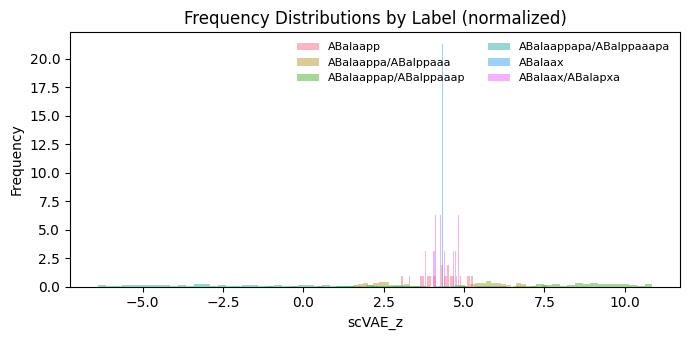

<Figure size 640x480 with 0 Axes>


--- Analyzing scVI data ---

--- scVI PCA + 1D UMAP Analysis ---
Input data shape: (466, 20222)
Data standardized
PCA completed: (466, 50)
Explained variance ratio (first 10 components): [0.06296489 0.02577491 0.01767279 0.0125502  0.0118377  0.01063869
 0.00984915 0.00891696 0.00835626 0.00755582]
Total explained variance: 0.357


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (466, 1)


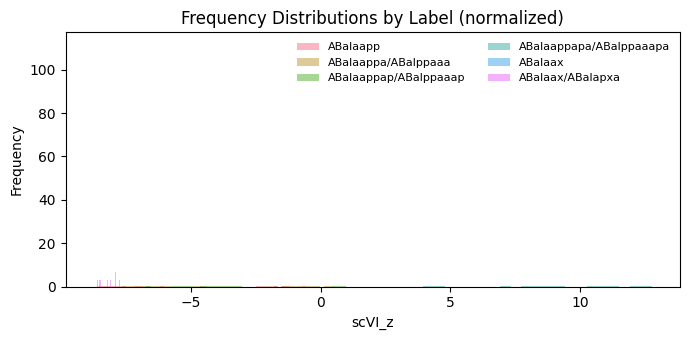

<Figure size 640x480 with 0 Axes>

✓ Successfully analyzed ABalaa_ABalaappapa

[12/20] Analyzing C_Capppaa...

TESTING PCA+UMAP+HISTOGRAM ANALYSIS FOR: C_Capppaa

--- Analyzing scVAE data ---

--- scVAE PCA + 1D UMAP Analysis ---
Input data shape: (436, 2000)
Data standardized
PCA completed: (436, 50)
Explained variance ratio (first 10 components): [0.04237105 0.03168139 0.02194626 0.01618308 0.01426536 0.01412924
 0.0137856  0.01319683 0.01273586 0.01088115]
Total explained variance: 0.469


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (436, 1)


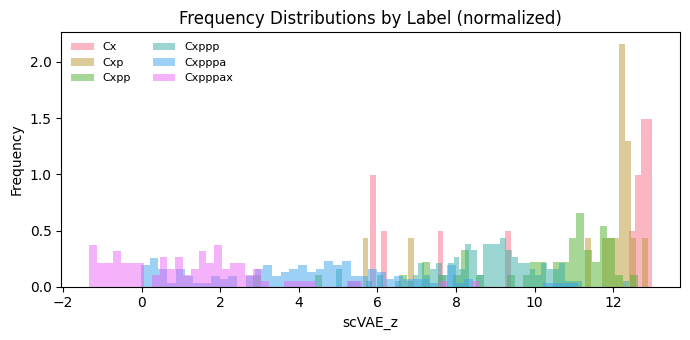

<Figure size 640x480 with 0 Axes>


--- Analyzing scVI data ---

--- scVI PCA + 1D UMAP Analysis ---
Input data shape: (436, 20222)
Data standardized
PCA completed: (436, 50)
Explained variance ratio (first 10 components): [0.07442289 0.02035225 0.01692267 0.01412645 0.01292676 0.01210803
 0.01206914 0.0112668  0.01094834 0.01047198]
Total explained variance: 0.418


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (436, 1)


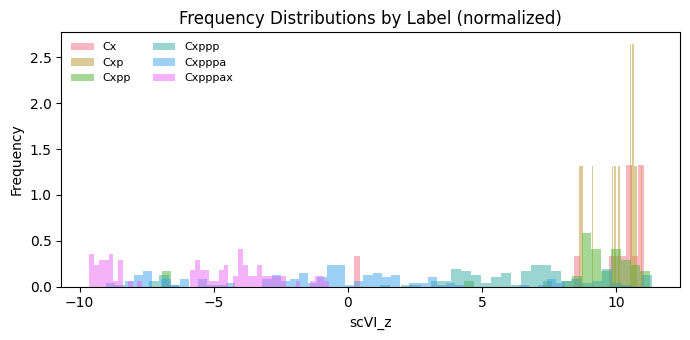

<Figure size 640x480 with 0 Axes>

✓ Successfully analyzed C_Capppaa

[13/20] Analyzing ABpl_ABplaapaapp...

TESTING PCA+UMAP+HISTOGRAM ANALYSIS FOR: ABpl_ABplaapaapp

--- Analyzing scVAE data ---

--- scVAE PCA + 1D UMAP Analysis ---
Input data shape: (583, 2000)
Data standardized
PCA completed: (583, 50)
Explained variance ratio (first 10 components): [0.02827123 0.02131391 0.01588526 0.01349839 0.01255744 0.0109014
 0.0101672  0.00908082 0.00837911 0.008181  ]
Total explained variance: 0.359


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (583, 1)


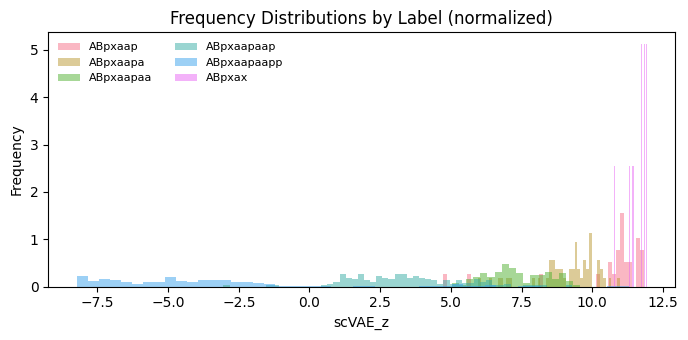

<Figure size 640x480 with 0 Axes>


--- Analyzing scVI data ---

--- scVI PCA + 1D UMAP Analysis ---
Input data shape: (583, 20222)
Data standardized
PCA completed: (583, 50)
Explained variance ratio (first 10 components): [0.05908293 0.01576853 0.01190766 0.00996377 0.0095081  0.00802914
 0.0077491  0.00749527 0.00711437 0.0069671 ]
Total explained variance: 0.316


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (583, 1)


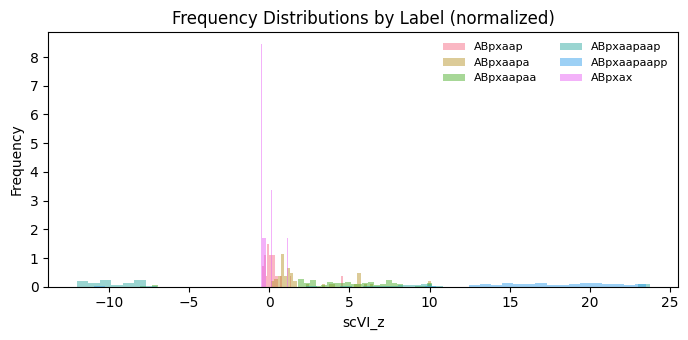

<Figure size 640x480 with 0 Axes>

✓ Successfully analyzed ABpl_ABplaapaapp

[14/20] Analyzing Ca_Capaaaa...

TESTING PCA+UMAP+HISTOGRAM ANALYSIS FOR: Ca_Capaaaa

--- Analyzing scVAE data ---

--- scVAE PCA + 1D UMAP Analysis ---
Input data shape: (413, 2000)
Data standardized
PCA completed: (413, 50)
Explained variance ratio (first 10 components): [0.0453254  0.03465005 0.02511709 0.01729527 0.01660506 0.01617471
 0.01476115 0.01368389 0.01222162 0.01212882]
Total explained variance: 0.481


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (413, 1)


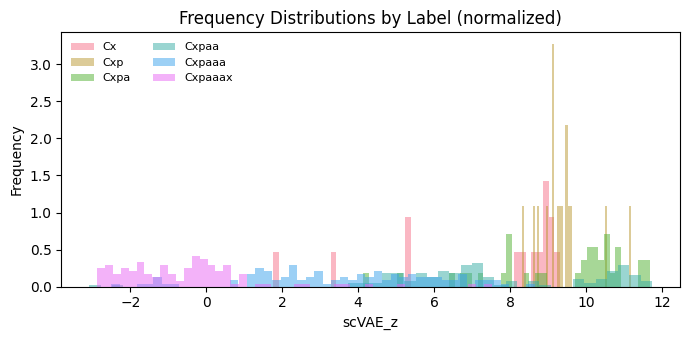

<Figure size 640x480 with 0 Axes>


--- Analyzing scVI data ---

--- scVI PCA + 1D UMAP Analysis ---
Input data shape: (413, 20222)
Data standardized
PCA completed: (413, 50)
Explained variance ratio (first 10 components): [0.07231174 0.02323417 0.01779602 0.014872   0.01359356 0.01223763
 0.01197961 0.01150048 0.01116129 0.01038302]
Total explained variance: 0.418


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (413, 1)


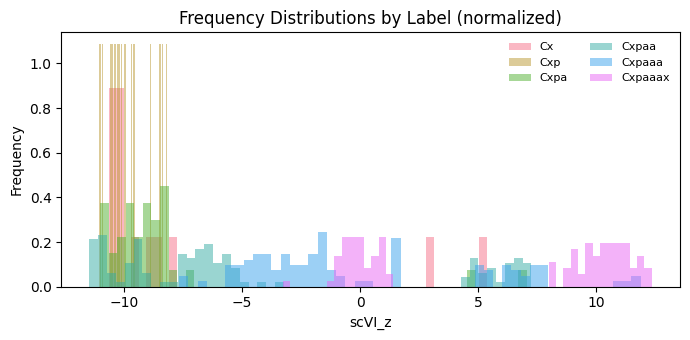

<Figure size 640x480 with 0 Axes>

✓ Successfully analyzed Ca_Capaaaa

[15/20] Analyzing Cpp_Cpppaap...

TESTING PCA+UMAP+HISTOGRAM ANALYSIS FOR: Cpp_Cpppaap

--- Analyzing scVAE data ---

--- scVAE PCA + 1D UMAP Analysis ---
Input data shape: (386, 2000)
Data standardized
PCA completed: (386, 50)
Explained variance ratio (first 10 components): [0.05339207 0.02718735 0.01855547 0.01697898 0.01372231 0.01308851
 0.01263272 0.01210615 0.01136579 0.01117787]
Total explained variance: 0.479


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (386, 1)


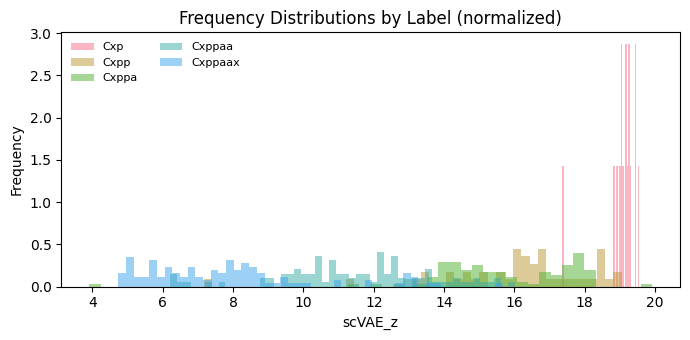

<Figure size 640x480 with 0 Axes>


--- Analyzing scVI data ---

--- scVI PCA + 1D UMAP Analysis ---
Input data shape: (386, 20222)
Data standardized
PCA completed: (386, 50)
Explained variance ratio (first 10 components): [0.0593641  0.02512403 0.01677785 0.01385705 0.00996764 0.00978647
 0.00900609 0.00883387 0.008595   0.00836687]
Total explained variance: 0.392


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (386, 1)


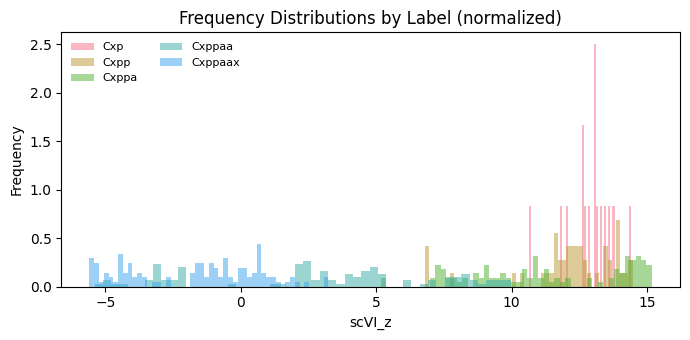

<Figure size 640x480 with 0 Axes>

✓ Successfully analyzed Cpp_Cpppaap

[16/20] Analyzing ABplpa_ABplpapppap...

TESTING PCA+UMAP+HISTOGRAM ANALYSIS FOR: ABplpa_ABplpapppap

--- Analyzing scVAE data ---

--- scVAE PCA + 1D UMAP Analysis ---
Input data shape: (174, 2000)
Data standardized
PCA completed: (174, 50)
Explained variance ratio (first 10 components): [0.04719809 0.03763802 0.02491021 0.02282652 0.02218605 0.02040423
 0.02003008 0.01887878 0.01854652 0.01762814]
Total explained variance: 0.631


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (174, 1)


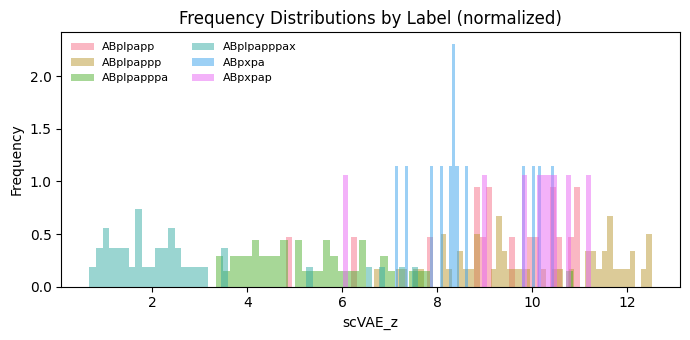

<Figure size 640x480 with 0 Axes>


--- Analyzing scVI data ---

--- scVI PCA + 1D UMAP Analysis ---
Input data shape: (174, 20222)
Data standardized
PCA completed: (174, 50)
Explained variance ratio (first 10 components): [0.08611704 0.02598365 0.02184955 0.02021051 0.01912463 0.01863499
 0.01795317 0.0148923  0.01453081 0.01318142]
Total explained variance: 0.594


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (174, 1)


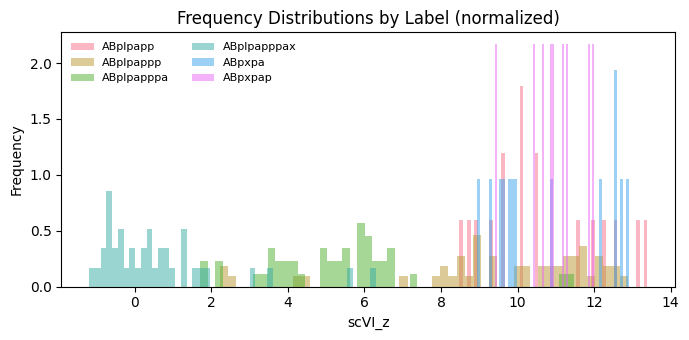

<Figure size 640x480 with 0 Axes>

✓ Successfully analyzed ABplpa_ABplpapppap

[17/20] Analyzing ABprap_ABprappapp...

TESTING PCA+UMAP+HISTOGRAM ANALYSIS FOR: ABprap_ABprappapp

--- Analyzing scVAE data ---

--- scVAE PCA + 1D UMAP Analysis ---
Input data shape: (257, 2000)
Data standardized
PCA completed: (257, 50)
Explained variance ratio (first 10 components): [0.04105236 0.03116143 0.03031737 0.02417618 0.02193161 0.01654025
 0.01480709 0.01415312 0.0136653  0.01252464]
Total explained variance: 0.523


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (257, 1)


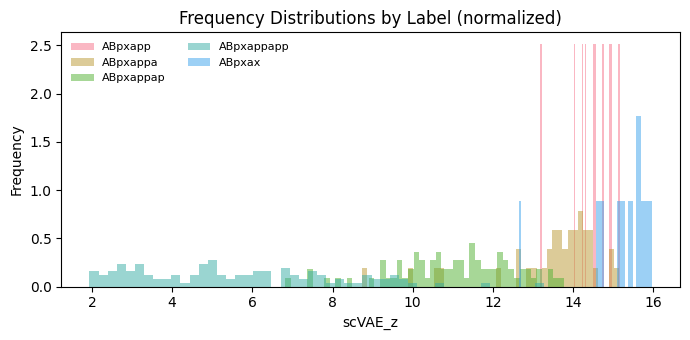

<Figure size 640x480 with 0 Axes>


--- Analyzing scVI data ---

--- scVI PCA + 1D UMAP Analysis ---
Input data shape: (257, 20222)
Data standardized
PCA completed: (257, 50)
Explained variance ratio (first 10 components): [0.07141106 0.02476045 0.02058359 0.01555494 0.01334473 0.01287945
 0.0124323  0.01198786 0.01136295 0.01055546]
Total explained variance: 0.481


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (257, 1)


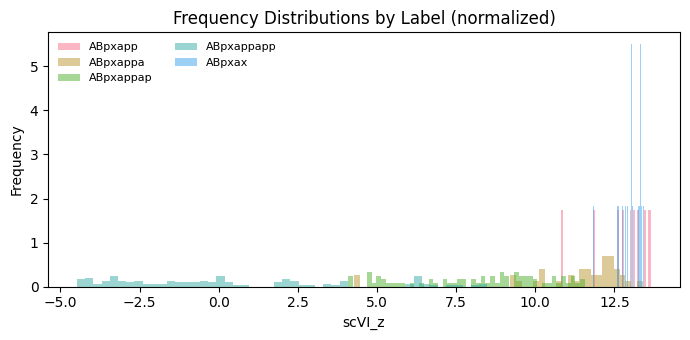

<Figure size 640x480 with 0 Axes>

✓ Successfully analyzed ABprap_ABprappapp

[18/20] Analyzing ABp_ABplpppppp...

TESTING PCA+UMAP+HISTOGRAM ANALYSIS FOR: ABp_ABplpppppp

--- Analyzing scVAE data ---

--- scVAE PCA + 1D UMAP Analysis ---
Input data shape: (243, 2000)
Data standardized
PCA completed: (243, 50)
Explained variance ratio (first 10 components): [0.04802801 0.03197747 0.02744434 0.02258104 0.01992251 0.01828024
 0.01606505 0.01415827 0.0136696  0.01290454]
Total explained variance: 0.559


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (243, 1)


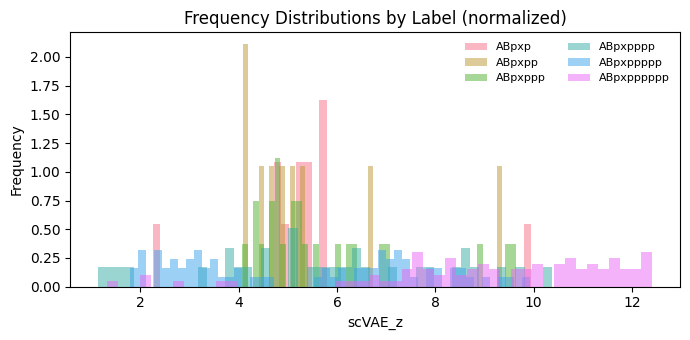

<Figure size 640x480 with 0 Axes>


--- Analyzing scVI data ---

--- scVI PCA + 1D UMAP Analysis ---
Input data shape: (243, 20222)
Data standardized
PCA completed: (243, 50)
Explained variance ratio (first 10 components): [0.1017288  0.02615092 0.02123341 0.01878008 0.01693424 0.01449663
 0.01314207 0.01197014 0.01188237 0.01107725]
Total explained variance: 0.529


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (243, 1)


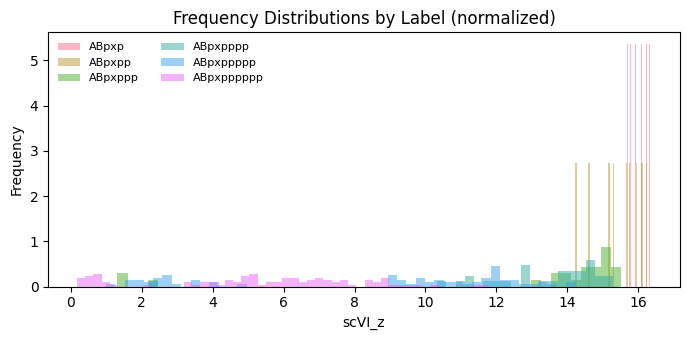

<Figure size 640x480 with 0 Axes>

✓ Successfully analyzed ABp_ABplpppppp

[19/20] Analyzing C_Capppap...

TESTING PCA+UMAP+HISTOGRAM ANALYSIS FOR: C_Capppap

--- Analyzing scVAE data ---

--- scVAE PCA + 1D UMAP Analysis ---
Input data shape: (436, 2000)
Data standardized
PCA completed: (436, 50)
Explained variance ratio (first 10 components): [0.04237105 0.03168139 0.02194626 0.01618308 0.01426536 0.01412924
 0.0137856  0.01319683 0.01273586 0.01088115]
Total explained variance: 0.469


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (436, 1)


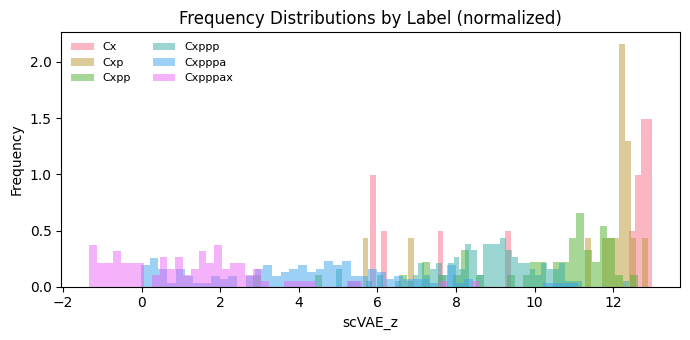

<Figure size 640x480 with 0 Axes>


--- Analyzing scVI data ---

--- scVI PCA + 1D UMAP Analysis ---
Input data shape: (436, 20222)
Data standardized
PCA completed: (436, 50)
Explained variance ratio (first 10 components): [0.07442289 0.02035225 0.01692267 0.01412645 0.01292676 0.01210803
 0.01206914 0.0112668  0.01094834 0.01047198]
Total explained variance: 0.418


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (436, 1)


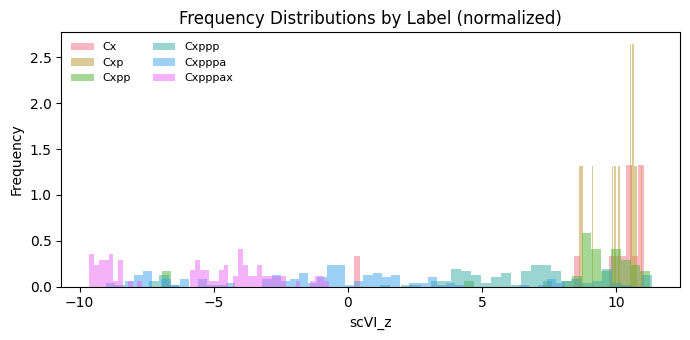

<Figure size 640x480 with 0 Axes>

✓ Successfully analyzed C_Capppap

[20/20] Analyzing ABprpa_ABprpapaaaa...

TESTING PCA+UMAP+HISTOGRAM ANALYSIS FOR: ABprpa_ABprpapaaaa

--- Analyzing scVAE data ---

--- scVAE PCA + 1D UMAP Analysis ---
Input data shape: (532, 2000)
Data standardized
PCA completed: (532, 50)
Explained variance ratio (first 10 components): [0.02516542 0.01604773 0.01018762 0.00976923 0.00933469 0.00883497
 0.00861731 0.00834933 0.00818413 0.0080578 ]
Total explained variance: 0.339


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (532, 1)


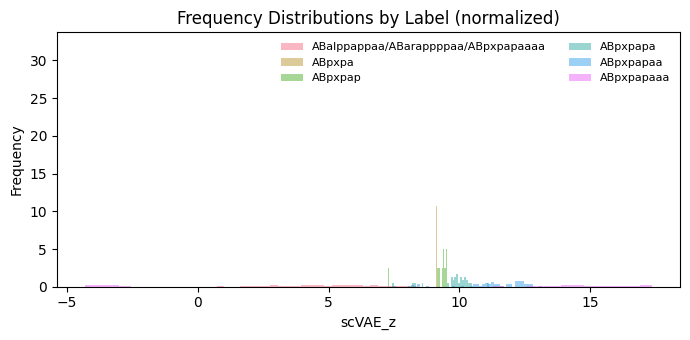

<Figure size 640x480 with 0 Axes>


--- Analyzing scVI data ---

--- scVI PCA + 1D UMAP Analysis ---
Input data shape: (532, 20222)
Data standardized
PCA completed: (532, 50)
Explained variance ratio (first 10 components): [0.05999606 0.01468108 0.01137757 0.01079296 0.01010969 0.00930814
 0.00851343 0.00727983 0.00712187 0.00646786]
Total explained variance: 0.321


/n/fs/ragr-data/users/viola/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


1D UMAP completed: (532, 1)


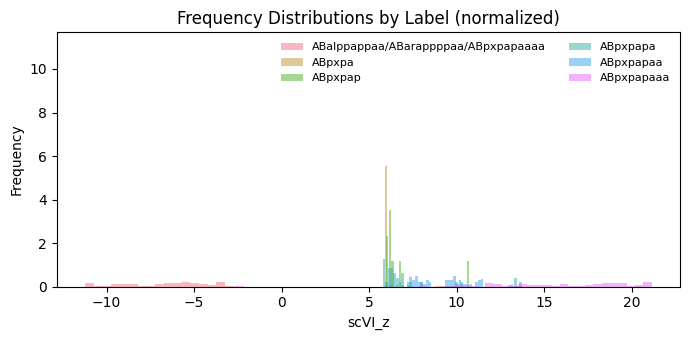

<Figure size 640x480 with 0 Axes>

✓ Successfully analyzed ABprpa_ABprpapaaaa

ANALYSIS COMPLETE
Successfully analyzed: 20/20 paths


In [18]:
# Apply PCA+UMAP+histogram analysis to all paths
def analyze_all_paths(all_data, max_paths=None, save_plots=False):
    """
    Apply PCA+UMAP+histogram analysis to all loaded paths.
    
    Parameters:
    -----------
    all_data : dict
        Dictionary containing all loaded data
    max_paths : int, optional
        Maximum number of paths to analyze (for testing)
    save_plots : bool
        Whether to save plots to files
    
    Returns:
    --------
    dict
        Dictionary containing analysis results for all paths
    """
    print(f"\n{'='*80}")
    print(f"RUNNING PCA+UMAP+HISTOGRAM ANALYSIS ON ALL PATHS")
    print(f"{'='*80}")
    
    all_results = {}
    successful_analyses = 0
    
    # Limit number of paths if specified
    paths_to_analyze = list(all_data.keys())
    if max_paths:
        paths_to_analyze = paths_to_analyze[:max_paths]
    
    print(f"Analyzing {len(paths_to_analyze)} paths...")
    
    for i, path_name in enumerate(paths_to_analyze):
        print(f"\n[{i+1}/{len(paths_to_analyze)}] Analyzing {path_name}...")
        
        try:
            # Run analysis
            results = test_single_path_analysis(path_name, all_data[path_name])
            
            if results:
                all_results[path_name] = results
                successful_analyses += 1
                
                # # Save plots if requested
                # if save_plots:
                #     # Create output directory
                #     output_dir = f"/n/fs/ragr-data/users/viola/structuredVAE/results/plots/{path_name}"
                #     os.makedirs(output_dir, exist_ok=True)
                    
                #     # Save scVAE plot
                #     if 'scvae' in results and 'scvae' in all_data[path_name]:
                #         fig_scvae = create_umap_lineage_histogram(
                #             all_data[path_name]['scvae'], "scVAE", path_name
                #         )
                #         if fig_scvae:
                #             fig_scvae.savefig(f"{output_dir}/scvae_umap_lineage_histogram.png", 
                #                             dpi=300, bbox_inches='tight')
                #             plt.close(fig_scvae)
                    
                #     # Save scVI plot
                #     if 'scvi' in results and 'scvi' in all_data[path_name]:
                #         fig_scvi = create_umap_lineage_histogram(
                #             all_data[path_name]['scvi'], "scVI", path_name
                #         )
                #         if fig_scvi:
                #             fig_scvi.savefig(f"{output_dir}/scvi_umap_lineage_histogram.png", 
                #                            dpi=300, bbox_inches='tight')
                #             plt.close(fig_scvi)
                
                print(f"✓ Successfully analyzed {path_name}")
            else:
                print(f"✗ Failed to analyze {path_name}")
                
        except Exception as e:
            print(f"✗ Error analyzing {path_name}: {e}")
    
    print(f"\n{'='*80}")
    print(f"ANALYSIS COMPLETE")
    print(f"Successfully analyzed: {successful_analyses}/{len(paths_to_analyze)} paths")
    print(f"{'='*80}")
    
    return all_results

# Run analysis on all paths (limit to first 5 for testing)
print("Running analysis on all paths...")
analysis_results = analyze_all_paths(all_data, max_paths=20, save_plots=True)


In [18]:
# Summary of analysis results
def summarize_analysis_results(analysis_results):
    """Create a summary of the PCA+UMAP analysis results."""
    print(f"\n{'='*80}")
    print(f"ANALYSIS RESULTS SUMMARY")
    print(f"{'='*80}")
    
    if not analysis_results:
        print("No analysis results to summarize")
        return None
    
    summary_data = []
    
    for path_name, results in analysis_results.items():
        path_summary = {'path_name': path_name}
        
        # scVAE results
        if 'scvae' in results:
            scvae_data = results['scvae']
            path_summary.update({
                'scvae_explained_variance': scvae_data.get('total_explained_variance', np.nan),
                'scvae_pca_components': len(scvae_data.get('explained_variance_ratio', [])),
                'scvae_umap_range': f"{scvae_data.get('X_umap_1d', np.array([])).min():.3f} to {scvae_data.get('X_umap_1d', np.array([])).max():.3f}"
            })
        else:
            path_summary.update({
                'scvae_explained_variance': np.nan,
                'scvae_pca_components': np.nan,
                'scvae_umap_range': 'N/A'
            })
        
        # scVI results
        if 'scvi' in results:
            scvi_data = results['scvi']
            path_summary.update({
                'scvi_explained_variance': scvi_data.get('total_explained_variance', np.nan),
                'scvi_pca_components': len(scvi_data.get('explained_variance_ratio', [])),
                'scvi_umap_range': f"{scvi_data.get('X_umap_1d', np.array([])).min():.3f} to {scvi_data.get('X_umap_1d', np.array([])).max():.3f}"
            })
        else:
            path_summary.update({
                'scvi_explained_variance': np.nan,
                'scvi_pca_components': np.nan,
                'scvi_umap_range': 'N/A'
            })
        
        summary_data.append(path_summary)
    
    # Create summary DataFrame
    summary_df = pd.DataFrame(summary_data)
    
    print(f"Analyzed {len(summary_df)} paths")
    print(f"\n--- PCA Explained Variance Summary ---")
    print(f"scVAE - Mean explained variance: {summary_df['scvae_explained_variance'].mean():.3f}")
    print(f"scVI - Mean explained variance: {summary_df['scvi_explained_variance'].mean():.3f}")
    
    print(f"\n--- UMAP Range Summary ---")
    print("scVAE UMAP ranges:")
    for _, row in summary_df.iterrows():
        print(f"  {row['path_name']}: {row['scvae_umap_range']}")
    
    print("scVI UMAP ranges:")
    for _, row in summary_df.iterrows():
        print(f"  {row['path_name']}: {row['scvi_umap_range']}")
    
    # Save summary
    output_file = "/n/fs/ragr-data/users/viola/structuredVAE/results/pca_umap_analysis_summary.csv"
    summary_df.to_csv(output_file, index=False)
    print(f"\nSummary saved to: {output_file}")
    
    return summary_df

# Create summary
if analysis_results:
    summary_df = summarize_analysis_results(analysis_results)
else:
    print("No analysis results to summarize")



ANALYSIS RESULTS SUMMARY
Analyzed 5 paths

--- PCA Explained Variance Summary ---
scVAE - Mean explained variance: 0.536
scVI - Mean explained variance: 0.494

--- UMAP Range Summary ---
scVAE UMAP ranges:
  ABprpa_ABprpaaaaap: -6.114 to 21.374
  ABa_ABarappaaa: 8.325 to 20.422
  ABprp_ABprpappaaa: 9.464 to 21.223
  E_Eplpp: -2.730 to 7.604
  ABp_ABprppapap: 2.836 to 14.534
scVI UMAP ranges:
  ABprpa_ABprpaaaaap: -15.179 to 19.816
  ABa_ABarappaaa: -6.350 to 8.097
  ABprp_ABprpappaaa: -2.830 to 13.626
  E_Eplpp: 1.229 to 13.687
  ABp_ABprppapap: -1.789 to 16.190

Summary saved to: /n/fs/ragr-data/users/viola/structuredVAE/results/pca_umap_analysis_summary.csv


In [ ]:
# Test the updated plotting functions with clear method labels
def test_updated_plotting(path_name, data_dict):
    """Test the updated plotting functions with method labels."""
    print(f"\n{'='*60}")
    print(f"TESTING UPDATED PLOTTING WITH METHOD LABELS: {path_name}")
    print(f"{'='*60}")
    
    scvae_data = data_dict.get('scvae')
    scvi_data = data_dict.get('scvi')
    
    if scvae_data is None or scvi_data is None:
        print("Missing data for one or both methods")
        return None
    
    # Test scVAE plotting
    print(f"\n--- Testing scVAE plot with method label ---")
    if 'X_umap_1d' in scvae_data.obsm:
        fig_scvae = create_umap_lineage_histogram(scvae_data, "scVAE", path_name)
        if fig_scvae:
            plt.show()
            plt.close()
    else:
        print("No UMAP data found for scVAE")
    
    # Test scVI plotting  
    print(f"\n--- Testing scVI plot with method label ---")
    if 'X_umap_1d' in scvi_data.obsm:
        fig_scvi = create_umap_lineage_histogram(scvi_data, "scVI", path_name)
        if fig_scvi:
            plt.show()
            plt.close()
    else:
        print("No UMAP data found for scVI")

# Test on the first available path
if all_data:
    first_path = list(all_data.keys())[0]
    print(f"Testing updated plotting on first path: {first_path}")
    test_updated_plotting(first_path, all_data[first_path])
else:
    print("No data available for testing")
